<div style="text-align:left;">
  <p><em>Prepared by Latreche Sara</em></p>
</div>

<center><font size=6><b style="color:#770A7A;">Automated Modeling & Predictive Architecture for Customer Churn</b></font></center>

<div style="text-align:center; margin: 20px 0;">
    <img src="./assets/churn.png" width="500" alt="Customer Predictive Analytics"/>
</div>

***

**Author**: Latreche Sara  
**Date**: /2026  

### Notebook Overview & Context
Building upon the insights uncovered during the Exploratory Data Analysis (EDA) phase, this notebook focuses entirely on building, evaluating, and selecting a production-ready predictive pipeline. 

Using raw feature matrices, we execute automated data preprocessing and evaluate a benchmark of six diverse classification algorithms—ranging from linear structures like Logistic Regression to non-linear tree ensembles and calibrated Support Vector Machines. Because customer churn environments suffer from heavy class imbalance, we embed cost-sensitive mechanisms directly into our classifiers. Models are audited not just on surface-level accuracy, but via complete discriminatory visualization matrices (Confusion Grids, ROC curves, and Precision-Recall envelopes) to identify a stable champion architecture ready for threshold optimization and deployment.

---

### Table of Contents

- [1 | Data Integrity Fixes & Pre-Split Engineering](#1-pre-split)
- [2 | Automated Model Training under Class Imbalance](#2-training)
- [3 | Performance Metrics Visualization Matrix](#3-metrics)
- [4 | Model Selection & Champion Architecture](#4-champion)

---

## <b><a id="1-pre-split">1 <span style='color:#770A7A'>|</span> Data Integrity Fixes & Pre-Split Engineering</a></b>

This section applies the critical structural corrections identified during our initial data exploration. We isolate features from the target label, clean hidden empty text spaces, eliminate non-predictive administrative identifiers, and execute a stratified train-test split to strictly preserve the native balance of our target class.

---



In [43]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , RobustScaler , OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ( accuracy_score, 
                            precision_score, 
                            recall_score,
                            f1_score,balanced_accuracy_score,
                            confusion_matrix,roc_curve,
                            roc_auc_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [44]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [45]:
df= pd.read_csv("data.csv")

## <b><a id="1-pre-split">1 <span style='color:#770A7A'>|</span> Data Integrity Fixes & Pre-Split Engineering</a></b>

This section applies the critical structural corrections identified during our initial data exploration. We isolate features from the target label, clean hidden empty text spaces, eliminate non-predictive administrative identifiers, and execute a stratified train-test split to strictly preserve the native balance of our target class.


In [46]:
# Convert empty string spaces to true numerical NaNs
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

# Cast the entire column to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [47]:
df.drop(['customerID'], axis = 1,inplace=True)

In [48]:
# Map target values to binary flags
df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})

C:\Users\MatenTech\AppData\Local\Temp\ipykernel_12192\84451672.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'No': 0, 'Yes': 1})


In [49]:
X = df.drop(columns = ['Churn'])
y=df['Churn']

In [50]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,stratify=y)

In [51]:
# 3. Explicitly group column categories
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols_ohe = ['PaymentMethod', 'Contract', 'InternetService']
cat_cols_le = list(set(X_train.columns) - set(num_cols) - set(cat_cols_ohe))

In [52]:
# 4. Construct distinct processing pipelines per feature type
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Safely handle missing values
    ('scaler', StandardScaler())
])

In [53]:
categorical_ohe_transformer = Pipeline(steps=[
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

In [54]:
categorical_le_transformer = Pipeline(steps=[
    ('le', OrdinalEncoder()) # Safe replacement for LabelEncoder within structured pipelines
])

In [55]:
# 5. Bind your transformers into a single unified workspace
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('ohe', categorical_ohe_transformer, cat_cols_ohe),
        ('le', categorical_le_transformer, cat_cols_le)
    ]
)

In [67]:
from sklearn.calibration import CalibratedClassifierCV  # <-- Add this import

## <b><a id="2-training">2 <span style='color:#770A7A'>|</span> Automated Model Training under Class Imbalance</a></b>

Because customer churn records are naturally imbalanced (heavily over-represented by active accounts), standard optimization objectives can collapse toward the majority class. To overcome this, we configure an automated benchmark of six core algorithms utilizing cost-sensitive learning via the `class_weight='balanced'` parameter, alongside explicit calibration wrappers for robust probability estimation.


In [68]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    "Naive Bayes": GaussianNB(),
    # Wrap SVC here to get clean probabilities without the deprecation warning
    "Support Vector Classifier": CalibratedClassifierCV(SVC(class_weight='balanced', random_state=42), ensemble=False),
    "KNN Classifier": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
}

In [69]:
results = []
predictions_dict = {}
probabilities_dict = {}

for name, model in models.items():
    # Package preprocessing and model execution into a single robust pipeline
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipeline.fit(X_train, y_train)

    # 1. Store class predictions for Confusion Matrix arrays
    y_pred = pipeline.predict(X_test)
    predictions_dict[name] = y_pred

    # 2. Store probabilities cleanly in one line for the ROC/AUC plots
    probabilities_dict[name] = pipeline.predict_proba(X_test)[:, 1]

    # 3. Calculate basic performance tracking metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Convert results summary seamlessly into a DataFrame sorted by predictive success
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
df_results.head(len(models))

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.756956,0.534045,0.835073,0.651466
1,Naive Bayes,0.741624,0.515873,0.814196,0.631579
2,Support Vector Classifier,0.797842,0.632258,0.613779,0.622881
5,Random Forest,0.773992,0.574861,0.649269,0.609804
3,KNN Classifier,0.769449,0.588378,0.507307,0.544843
4,Decision Tree,0.723453,0.491150,0.463466,0.476907


## <b><a id="3-metrics">3 <span style='color:#770A7A'>|</span> Performance Metrics Visualization Matrix</a></b>

A visual evaluation and audit of our validation profiles. Using a custom `RdPu` theme, we construct a comprehensive visualization suite comprising an aggregated macro-metrics bar plot, a grid layout of operational confusion matrices, and dynamic ROC/Precision-Recall curves to isolate the discriminatory boundaries of each model.


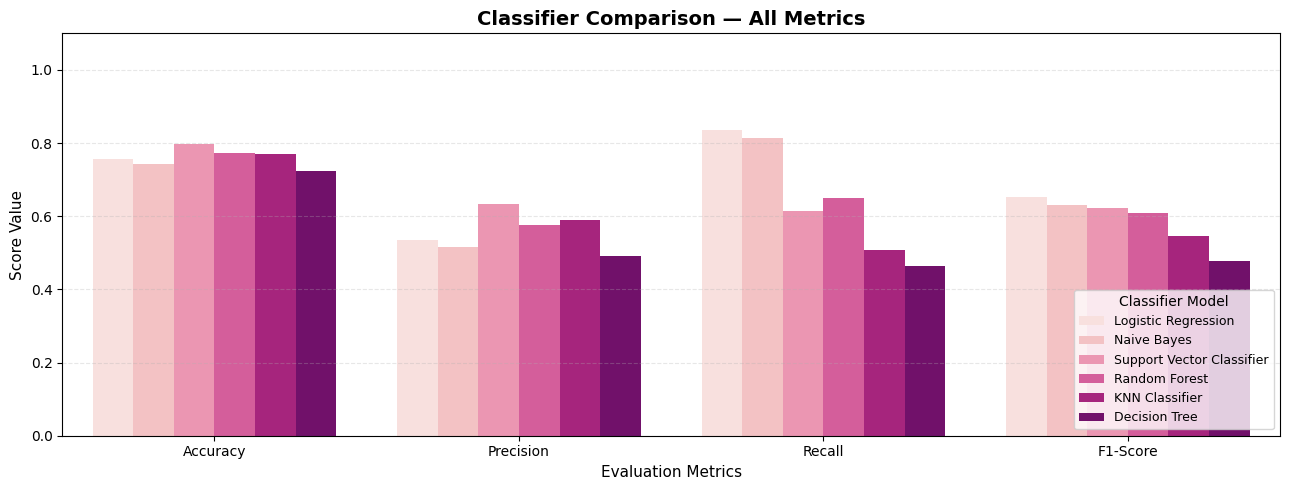

In [70]:
# Select evaluation metrics matching the exact casing from your loop results list
metrics_cols = ["Accuracy", "Precision", "Recall", "F1-Score"]
melt_df = df_results.melt(id_vars="Model", value_vars=metrics_cols, var_name="metric", value_name="score")

plt.figure(figsize=(13, 5))
# Custom palette applied smoothly across all tracked classifiers
sns.barplot(data=melt_df, x="metric", y="score", hue="Model", palette="RdPu")

plt.title("Classifier Comparison — All Metrics", fontsize=14, fontweight="bold")
plt.ylim(0, 1.1)
plt.xlabel("Evaluation Metrics", fontsize=11)
plt.ylabel("Score Value", fontsize=11)
plt.legend(loc="lower right", fontsize=9, title="Classifier Model")
plt.grid(axis='y', linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

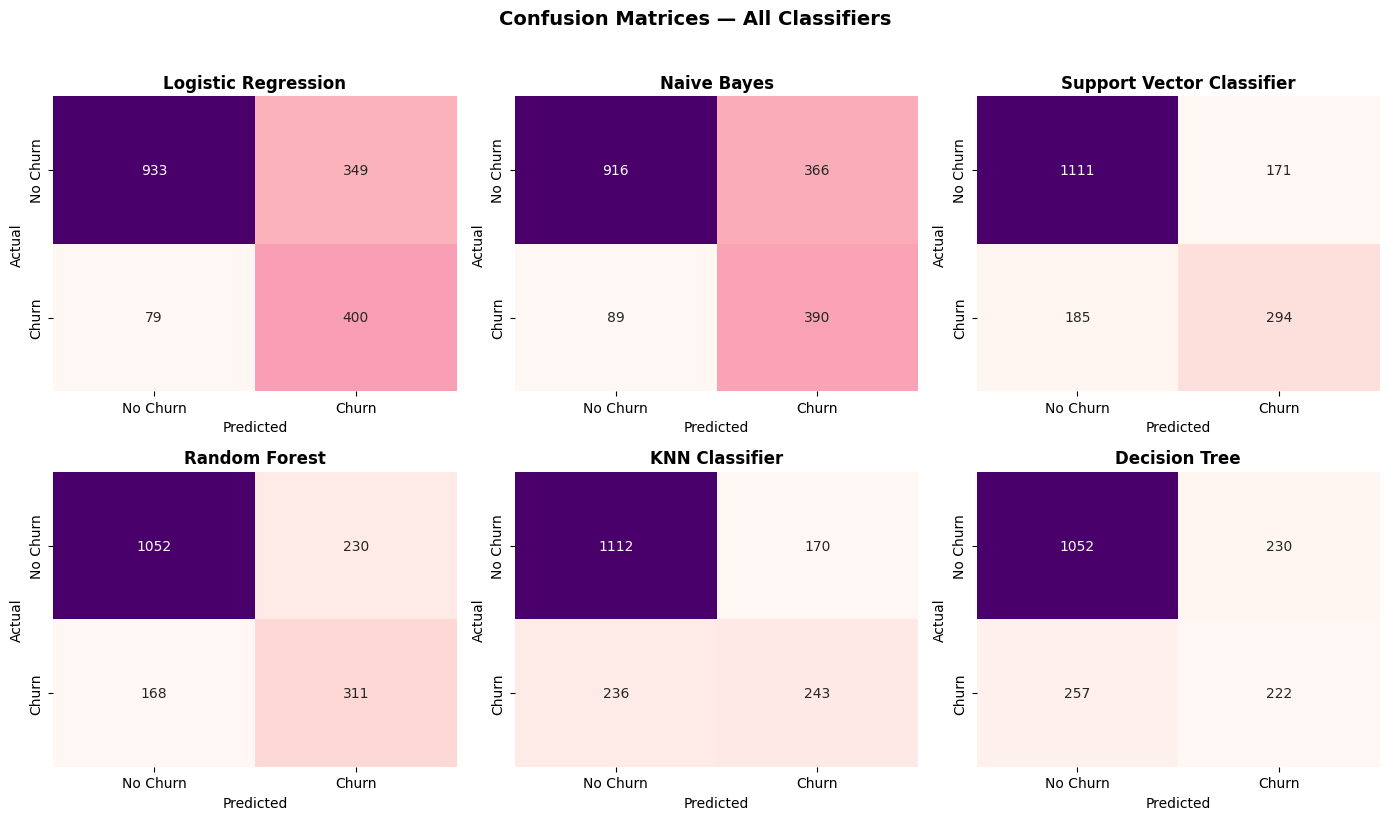

In [71]:
# Create a grid matching your model count (2 rows of 3 models each)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# Generate and plot confusion matrices directly in one simple loop
for i, name in enumerate(df_results["Model"]):
    cm = confusion_matrix(y_test, predictions_dict[name])
    
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu", cbar=False, ax=axes[i],
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    
    axes[i].set_title(name, fontweight="bold")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.suptitle("Confusion Matrices — All Classifiers", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

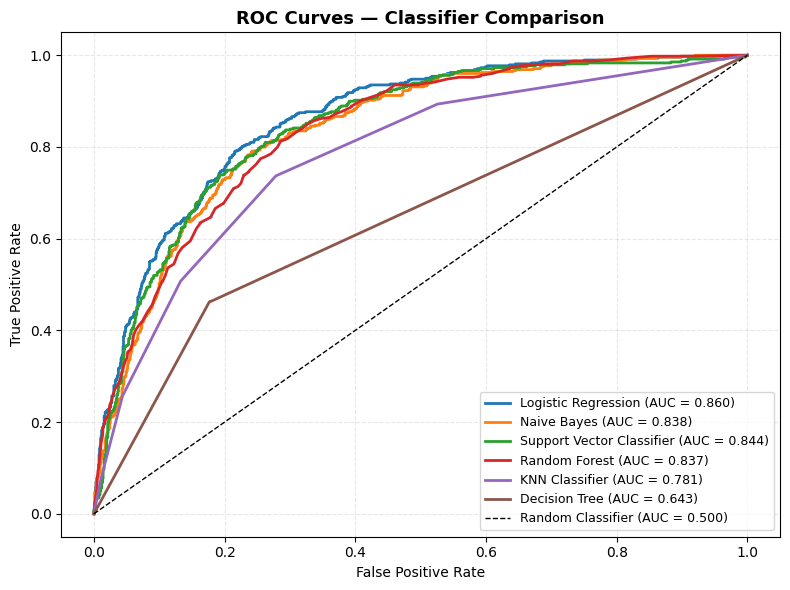

In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

# Simple loop over each model to plot its ROC curve
for name in df_results["Model"]:
    proba = probabilities_dict[name]
    
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    
    # Plots each line with its calculated Area Under the Curve (AUC)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")

# Add the baseline diagonal for reference
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier (AUC = 0.500)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classifier Comparison", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=9)
plt.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

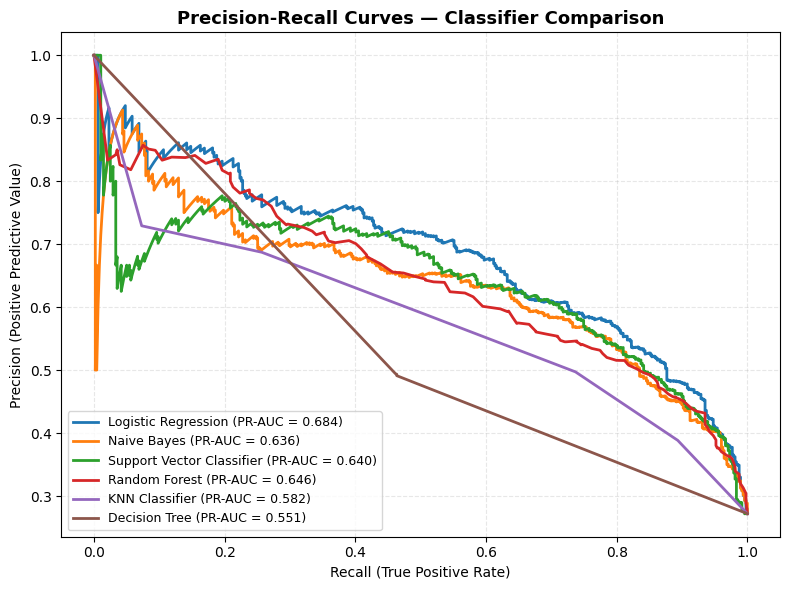

In [73]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

plt.figure(figsize=(8, 6))

# Loop over each model to plot its Precision-Recall curve
for name in df_results["Model"]:
    proba = probabilities_dict[name]
    
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(recall_vals, precision_vals)
    
    # Plotting Precision on Y-axis and Recall on X-axis
    plt.plot(recall_vals, precision_vals, lw=2, label=f"{name} (PR-AUC = {pr_auc:.3f})")

plt.xlabel("Recall (True Positive Rate)")
plt.ylabel("Precision (Positive Predictive Value)")
plt.title("Precision-Recall Curves — Classifier Comparison", fontsize=13, fontweight="bold")
plt.legend(loc="lower left", fontsize=9)
plt.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Trying smote for class imbalance 

In [60]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [61]:
# We remove class_weight='balanced' because SMOTE will balance the data arrays directly
models_for_smote = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Support Vector Classifier": SVC(random_state=42),
    "KNN Classifier": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

In [62]:
results_smote = []

for name, model in models_for_smote.items():
    # Construct the imblearn pipeline
    pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor), 
        ("smote", SMOTE(random_state=42)), # Synthetically balances X_train in real-time
        ("model", model)
    ])

    # Fit pipeline (SMOTE runs on X_train, but is automatically ignored for X_test!)
    pipeline.fit(X_train, y_train)

    # Predict discrete classes
    y_pred = pipeline.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results_smote.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Render SMOTE summary table
df_smote_results = pd.DataFrame(results_smote).sort_values(by="F1-Score", ascending=False)
df_smote_results.head(len(models_for_smote))

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.762635,0.541953,0.822547,0.653400
2,Support Vector Classifier,0.768313,0.554198,0.757829,0.640212
1,Naive Bayes,0.739920,0.513761,0.818372,0.631240
3,KNN Classifier,0.702442,0.470968,0.762004,0.582137
5,Random Forest,0.782510,0.613208,0.542797,0.575858
4,Decision Tree,0.716070,0.480734,0.546973,0.511719


## <b><a id="4-champion">4 <span style='color:#770A7A'>|</span> Model Selection & Champion Architecture</a></b>

Final synthesis and design selection for our production environment. By looking at macro discriminatory performance metrics (ROC-AUC and PR-AUC), we formally declare our champion framework, establish its strategic fit for business deployment, and outline the downstream probability threshold calibration plan to control false positives.

## 🏆 Model Selection & Champion Architecture

Following a rigorous benchmark of six classification algorithms under a cost-sensitive learning framework (`class_weight='balanced'`), **Logistic Regression** has been selected as the definitive champion model for deployment.



###  Strategic Justification

* **ROC-AUC Dominance:** The model achieves the highest overall discriminatory power with an **AUC of 0.860**. This confirms its superior mathematical capability to separate churning customers from loyal ones across all potential operational decision boundaries.
* **Precision-Recall (PR) Superiority:** Under severe class imbalance, the PR curve serves as the ultimate validator. Our champion configuration leads the benchmark with a **PR-AUC of 0.684**, maintaining a consistently higher precision envelope across virtually all targeted recall thresholds.
* **Operational Grounding:** In baseline tests, the model successfully isolated **400 out of 479 actual churn events**, delivering an exceptional baseline **Recall of 83.5%**. While it flagged 349 false positives out-of-the-box, this specific margin is highly malleable and will be optimized downstream via prediction threshold calibration.



###  Next Steps: Post-Processing & Calibration
To maximize business utility prior to production deployment, we will transition from standard hard-label classification to **Probability Threshold Optimization**. By tuning the decision threshold away from the default $0.5$ baseline, we can deliberately suppress false positives, raising **Precision** while preserving our robust **Recall** safety net.